In [1]:
import os
os.chdir("..")

In [2]:
from src.data_processing.size_dataset import ParticleDataset
from src.models.resnet import ResNet18
from src.trainers.trainersize import TrainerSize, generate_label_distribution
from torch.utils.data import DataLoader

In [3]:
# import os
# os.chdir("/nfshome/narjis")
dataset_path = "/nfshome/narjis/Downloads/brightfield_particles_y.hdf5"
classes = [0,1]
plot_dataset = ParticleDataset(
    h5_path=dataset_path,
    classes=classes,
    mean=None,
    std=None,
    padding=False,
    transform=None,
    indices=None,
)

Computed statistics: mean = 7541.1983, std = 1316.1215


In [10]:
model.resnet.fc

Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=2, bias=True)
)

In [15]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet18(num_classes=1)  # For regression, output is a single value
model.resnet.fc = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
checkpoint_path = "/nfshome/narjis/workspace/iscat/experiments/runs/size_prediction/ResNet18_2025-06-05_15-17-15/best_model.pth"
if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device)['model_state_dict'])
model = model.to(device)

Using cache found in /nfshome/narjis/.cache/torch/hub/pytorch_vision_v0.10.0
/tmp/ipykernel_2523115/3567916253.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.loa

In [30]:
model.eval()
target_distribution = generate_label_distribution(num_points=30000, mean=302, std=25, min_value=150, max_value=None)
# images = [plot_dataset[i][0].unsqueeze(0) for i in range(len(plot_dataset))]
# images = torch.cat(images, dim=0).to(device)
dataloader = DataLoader(
        plot_dataset,
        batch_size=4000,
        drop_last=False,
    )

In [33]:
def contrast_from_middle_rows(images: torch.Tensor) -> torch.Tensor:
    """
    Compute standard deviation (RMS contrast) from the 4 middle rows of each image in a batch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
    
    Returns:
        Tensor of shape (B,) with contrast values.
    """
    B, C, H, W = images.shape
    mid = H // 2
    rows = images[:, :, mid - 2:mid + 2, :]  # (B, C, 4, W)

    gray = rows.mean(dim=1)  # Convert to grayscale: (B, 4, W)
    contrast = gray.std(dim=(1, 2))  # Compute std over height and width

    return contrast  # shape: (B,)

In [36]:
import torch
from torch.utils.data import DataLoader
# Create DataLoader for the dataset
predictions = []
labels = []
contrasts = []
model.eval()  # Set the model to evaluation mode
for batch,label in dataloader:
    images = batch.to(device)
    with torch.no_grad():
        outputs = model.resnet(images)
        predictions.append(outputs.cpu().numpy().flatten())
    labels.append(label.numpy().flatten())
    contrasts.append(contrast_from_middle_rows(images))
predictions = torch.cat([torch.tensor(pred) for pred in predictions], dim=0).numpy()
labels = torch.cat([torch.tensor(label) for label in labels], dim=0).numpy()
contrasts = torch.cat([torch.tensor(contrast)for contrast in contrasts], dim=0).cpu().numpy()

/tmp/ipykernel_2523115/3622216739.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  contrasts = torch.cat([torch.tensor(contrast)for contrast in contrasts], dim=0).cpu().numpy()


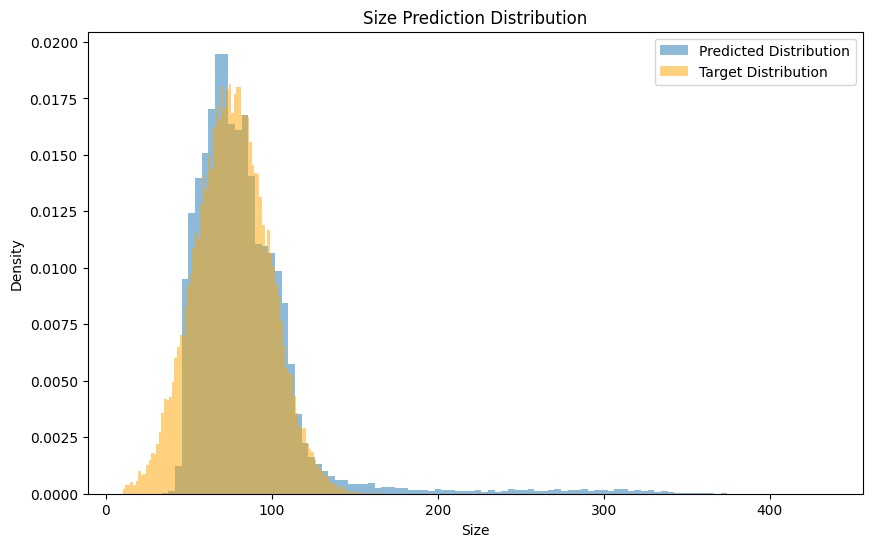

In [31]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predictions[labels==0], bins=100, density=True, alpha=0.5, label='Predicted Distribution')
ax.hist(target_distribution[:30000], bins=100, density=True, alpha=0.5, label='Target Distribution', color='orange')
ax.set_title('Size Prediction Distribution')
ax.set_xlabel('Size')
ax.set_ylabel('Density')
ax.legend()
plt.show()

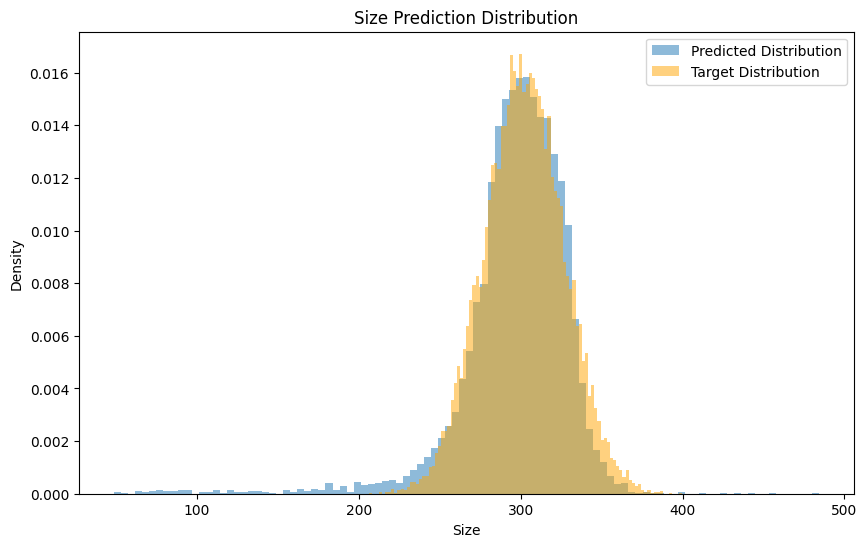

In [32]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(predictions[labels==1], bins=100, density=True, alpha=0.5, label='Predicted Distribution')
ax.hist(target_distribution[30000:], bins=100, density=True, alpha=0.5, label='Target Distribution', color='orange')
ax.set_title('Size Prediction Distribution')
ax.set_xlabel('Size')
ax.set_ylabel('Density')
ax.legend()
plt.show()

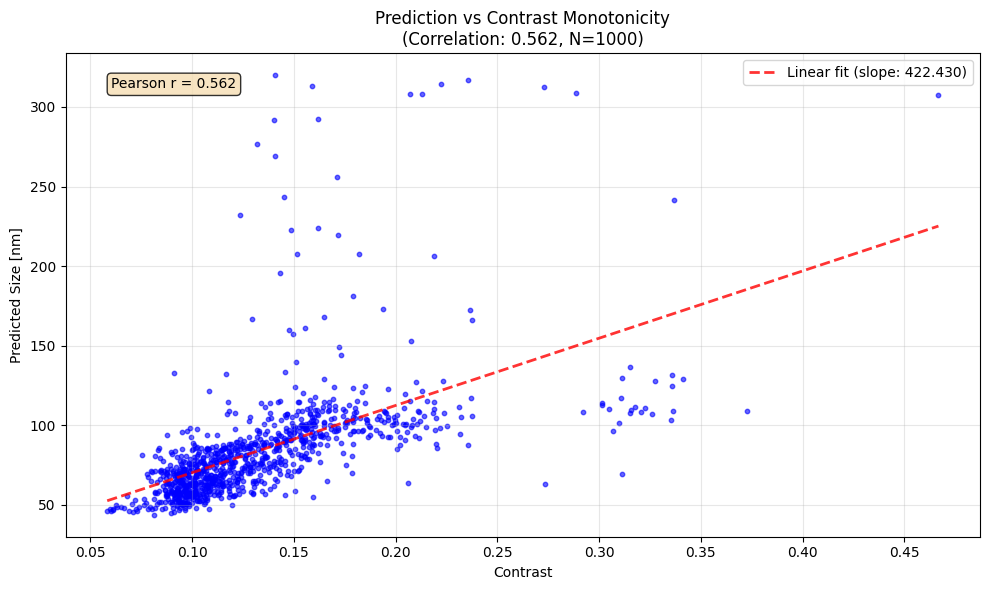

In [46]:
import numpy as np
random_indices = np.random.choice(np.where(labels==0)[0], size=1000, replace=False)
contrasts_80 = contrasts[random_indices]
predictions_80 = predictions[random_indices]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
ax.scatter(contrasts_80, predictions_80, alpha=0.6, s=10, color='blue')

# Add trend line (polynomial fit)
z = np.polyfit(contrasts_80, predictions_80, 1)  # Linear fit
p = np.poly1d(z)
x_trend = np.linspace(contrasts_80.min(), contrasts_80.max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope: {z[0]:.3f})')

# Calculate correlation coefficient
correlation = np.corrcoef(contrasts_80, predictions_80)[0, 1]

ax.set_xlabel('Contrast')
ax.set_ylabel('Predicted Size [nm]')
ax.set_title(f'Prediction vs Contrast Monotonicity\n(Correlation: {correlation:.3f}, N={len(contrasts_80)})')
ax.legend()
ax.grid(True, alpha=0.3)

# Add correlation coefficient as text
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}', 
        transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()

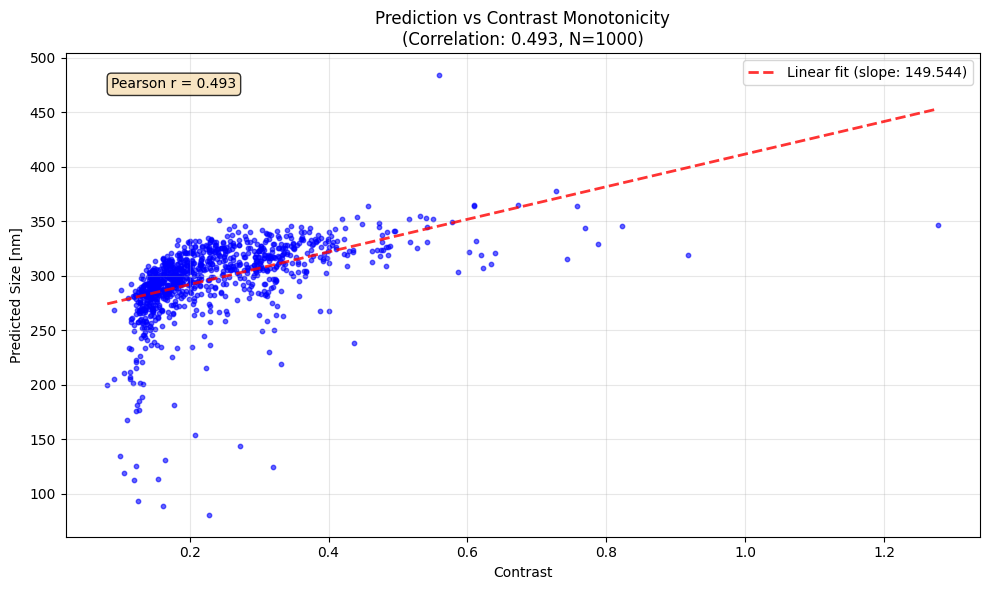

In [47]:
import numpy as np
random_indices = np.random.choice(np.where(labels==1)[0], size=1000, replace=False)
contrasts_80 = contrasts[random_indices]
predictions_80 = predictions[random_indices]
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# Scatter plot
ax.scatter(contrasts_80, predictions_80, alpha=0.6, s=10, color='blue')

# Add trend line (polynomial fit)
z = np.polyfit(contrasts_80, predictions_80, 1)  # Linear fit
p = np.poly1d(z)
x_trend = np.linspace(contrasts_80.min(), contrasts_80.max(), 100)
ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope: {z[0]:.3f})')

# Calculate correlation coefficient
correlation = np.corrcoef(contrasts_80, predictions_80)[0, 1]

ax.set_xlabel('Contrast')
ax.set_ylabel('Predicted Size [nm]')
ax.set_title(f'Prediction vs Contrast Monotonicity\n(Correlation: {correlation:.3f}, N={len(contrasts_80)})')
ax.legend()
ax.grid(True, alpha=0.3)

# Add correlation coefficient as text
ax.text(0.05, 0.95, f'Pearson r = {correlation:.3f}', 
        transform=ax.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()